# FEM Pendulum: Basics

In this FEM tutorial section, we will build a deformable pendulum model using the Finite Element Method (FEM) with NGSolve.

1. **Basics** (this tutorial): We set up the basic model of a deformable pendulum without contact and external torque.
2. **[Torque Application](02_fem_pendulum_torque.ipynb)**: We extend the basic model by applying an external torque at the pivot point.
3. **[Contact Handling](03_fem_pendulum_contact.ipynb)**: We further extend the model by adding contact handling with a wall.

Following references were used to implement the model:
- [Nonlinear Elasticity - NGSolve 24](https://docu.ngsolve.org/ngs24/SaS/nonlinearelasticity.html)
- [Elastic Pendulum - NGS Tutorial 2024](https://docu.ngsolve.org/ngs24/tutorials/00_dynamics.html)
- [Contact Problems - NGS Docu Interactive Tutorial](https://docu.ngsolve.org/latest/i-tutorials/unit-6.2-contact/contact.html)
- [An Interactive Introduction to the Finite Element Method, Joachim Schöberl, TU Wien, ASC](https://jschoeberl.github.io/iFEM/intro.html)

:::{figure} /_static/fem_pendulum_swing.gif
:alt: FEM pendulum swing
:width: 600px

FEM pendulum swing.
:::

## Overview
We construct a planar pendulum from scratch:
1) geometry, 
2) mesh,
3) material law,
4) mixed FE space with hinge constraint,
5) nonlinear energy, and
6) a Newmark time integrator.

This notebook focuses on the core mechanics before adding torque actuation or wall contact.


## Learning Goals
- Build a 2D pendulum mesh with labeled boundaries
- Define a Neo-Hookean material model (hyperelasticity)
- Set up mixed FE spaces with a hinge constraint using `NumberSpace`
- Assemble the nonlinear weak form (internal forces + inertia + gravity + constraints)
- Time-integrate by solving the nonlinear weak form with Newton's method (NGSolve: `NewtonMinimization`) and Newmark-style updates
- Extract a rigid-body proxy angle from the deformable solution


## Prerequisites and Setup
You should be comfortable with basic FEM ideas (weak form, trial/test spaces) and nonlinear elasticity. The notebook uses NGSolve + Netgen. All quantities are in SI units.

Assumptions used here:
- 2D planar model with an out-of-plane thickness
- Hyperelastic (Neo-Hookean) material
- No damping, no contact, no external torque

Documentation note: The NGSolve `Draw(...)` scenes are `ipywidgets`-based. To get the interactive WebGUI scenes in the rendered HTML docs, run this notebook once and save the widget state (JupyterLab: Command Palette → "Save Notebook Widget State") before building the docs.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from netgen.occ import *
from ngsolve import *
from ngsolve.solvers import NewtonMinimization
from ngsolve.webgui import Draw

## Physical Model and Governing Equation
We model a deformable pendulum in 2D (with a constant out-of-plane thickness) using a displacement field $u(X,t)$.

A standard nonlinear elastodynamics form in the reference configuration is:

$$\rho_0 \ddot{u} = \nabla_0 \cdot P + b \quad \text{in } \Omega_0$$

where
- $\rho_0$ is the reference density (here: $\rho_0 = \rho\, t$ for 2D-thickness scaling),
- $P$ is the first Piola-Kirchhoff stress,
- $b$ is a body force (gravity).

In a hyperelastic model, internal forces come from a strain energy density $W(F)$ with

$$F = I + \nabla_0 u, \quad P = \partial W/\partial F.$$

We do **not** assemble a single global stiffness matrix once. Instead, we solve the nonlinear weak form at each time step using Newton iterations (residual + linearization).


## Material Law
We use a Neo-Hookean hyperelastic model. This is suitable for large deformations and **avoids the limitations of linear elasticity for large rotations.**

### Dimensional reduction: 2D plane stress
The pendulum is three-dimensional, but we reduce to a 2D planar model for **reduced computational cost**. The reduction is consistent under a **plane-stress** assumption, which is appropriate for a **thin** body with $\sigma_{zz} = 0$ (free out-of-plane surfaces). This will be applied consistently throughout the tutorial series: the pendulum thickness is small, mass is scaled by thickness, and the constitutive law uses plane-stress-adjusted Lamé parameters.

Under plane stress, the out-of-plane stress $\sigma_{zz}$ is eliminated statically, which modifies the first Lamé parameter:

$$
\lambda^{*} = \frac{E\,\nu}{1 - \nu^{2}}, \qquad \mu = \frac{E}{2(1+\nu)}.
$$

The shear modulus $\mu$ is unchanged. Using $\lambda^{*}$ in the 2D strain energy yields the correct plane-stress response at small strains and a consistent finite-strain extension.

### Material Parameters
We specify Young's modulus and Poisson's ratio, then compute the plane-stress Lamé parameters.

In [2]:
E = 2.1e11      # Young's modulus in Pa
nu = 0.3        # Poisson's ratio

# Plane-stress Lamé parameters (σ_zz = 0)
lam = E * nu / (1 - nu * nu)
mu = E / (2 * (1 + nu))

### Deformation Gradient

The deformation gradient is $F$, and the right Cauchy-Green tensor is $C$ are defined as:
$$F = I + \nabla u, \quad C = F^T F$$

In [3]:
def C(u):
    F = Id(2) + Grad(u)
    return F.trans * F

### Hyperelastic Material Strain Energy Density Function

We use the Neo-Hookean strain energy density function:
$$\psi(C) = \frac{\mu}{2}\bigl(\mathrm{tr}(C - I) + \tfrac{2\mu}{\lambda}\,(\det C)^{-\lambda/(2\mu)} - 1\bigr)$$

In [4]:
def psi(C, lam, mu):
    return (mu / 2) * (Trace(C - Id(2)) + (2 * mu / lam) * (Det(C))**(-lam / (2 * mu)) - 1)

### Stress Tensors (for post-processing)

The 2nd Piola-Kirchhoff stress is derived from the strain energy density:

$$S = 2\,\frac{\partial \psi}{\partial C}.$$

For the Neo-Hookean energy, differentiating with respect to $C$ gives

$$S = \mu\bigl(I - (\det C)^{-\lambda^{*}/(2\mu)}\, C^{-1}\bigr).$$

For a meaningful visualization we push $S$ forward to the **Cauchy (true) stress** in the current configuration:

$$\sigma = \frac{1}{J}\, F\, S\, F^{T}, \qquad J = \det F.$$

Under the plane-stress assumption ($\sigma_{zz} = \sigma_{xz} = \sigma_{yz} = 0$), the **von Mises** equivalent stress reduces to

$$\sigma_{\mathrm{vM}} = \sqrt{\sigma_{xx}^{2} + \sigma_{yy}^{2} - \sigma_{xx}\,\sigma_{yy} + 3\,\sigma_{xy}^{2}}.$$

> **Note:** In the time-stepping loop we use the energy-based `Variation(...)` approach, which lets NGSolve derive residual and tangent automatically. The explicit stress expressions below are provided for **post-processing** only and are not called during the solve.

In [6]:
def PK2_neo_hookean(u, lam, mu):
    """2nd Piola-Kirchhoff stress for the Neo-Hookean model.

    S = mu * (I - det(C)^(-lam/(2*mu)) * C^{-1})
    """
    CC = C(u)
    return mu * (Id(2) - Det(CC)**(-lam / (2 * mu)) * Inv(CC))

def cauchy_stress(u, lam, mu):
    """Cauchy (true) stress: sigma = (1/J) F S F^T."""
    F = Id(2) + Grad(u)
    J = Det(F)
    S = PK2_neo_hookean(u, lam, mu)
    return (1 / J) * F * S * F.trans

def von_mises(u, lam, mu):
    """Plane-stress von Mises: sigma_vM = sqrt(sxx^2 + syy^2 - sxx*syy + 3*sxy^2)."""
    sigma = cauchy_stress(u, lam, mu)
    sxx, syy, sxy = sigma[0, 0], sigma[1, 1], sigma[0, 1]
    return sqrt(sxx * sxx + syy * syy - sxx * syy + 3 * sxy * sxy)

## Create Geometry and Mesh
We define a simple pendulum: a rectangular rod with a circular head and a hole. The top edge is labeled as the rotation (hinge) boundary.


### Geometry Parameters
Key geometric parameters (meters):
- `r_rod`: half-width of the rod
- `r_head`: radius of the pendulum head
- `r_hole`: hole radius (subtracted)
- `l_center`: length from pivot to head center


In [7]:
r_rod = 0.015   # rod radius in meters
r_hole = 0.03   # hole radius in meters
r_head = 0.06   # head radius in meters
l_center = 0.24 # length to center of head in meters

## Create Geometry

### Named Regions and Integration Measures
In Netgen/NGSolve we can *name* materials (faces) and boundaries (edges). These names show up in the integration measures:

- `dx("pendulum")`: integrate over the *material region* named `pendulum`
- `ds("rotation")`: integrate over the *boundary* named `rotation`

This is how we keep the weak form readable and ensure each term is integrated on the correct part of the domain.


In [8]:
bar = MoveTo(-r_rod, 0).Rectangle(2 * r_rod, l_center).Face()
bar.edges.Min(Y).name = "rotation"
bar.edges.Min(Y).maxh = r_rod / 10
bar.faces.name = "bar"
bar.faces.maxh = r_rod / 2

hole = Circle((0, l_center), r_hole).Face()
hole.faces.name = "hole"
hole.edges.maxh = r_head / 20

circ = Circle((0, l_center), r_head).Face()
circ.edges.maxh = r_head / 20
circ.faces.name = "circ"
circ.faces.maxh = r_head / 5
circ.edges.name = "contact_head"

head = circ - hole
pendulum = head + bar - hole

pendulum = pendulum.Rotate(Axis((0.0, 0, 0), (0, 0, 1)), 180)
pendulum.name = "pendulum"

# Refine min y vertices on edge 0 and edge 1
pendulum.vertices[0].maxh = r_rod / 20
pendulum.vertices[1].maxh = r_rod / 20


### Generate Mesh
We generate a curved, quadratic mesh for better geometric accuracy of the circular head.


In [10]:
geo = OCCGeometry(pendulum, dim=2)

max_element_size = 0.03
mesh_order = 2

mesh = Mesh(geo.GenerateMesh(maxh=max_element_size))
mesh.Curve(mesh_order)

scene_mesh = Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [11]:
print(f"Number of elements in the mesh: {mesh.ne}")
print(f"Number of vertices in the mesh: {mesh.nv}")

Number of elements in the mesh: 1196
Number of vertices in the mesh: 720


## Initialize FE Spaces

### Hinge Constraint
Without constraints, a free elastic body under gravity would translate and fall. A pendulum needs a *pivot* that prevents translation at the top while still allowing rotation.

In this tutorial we enforce a **mean-zero displacement constraint** on the top edge `rotation` using Lagrange multipliers. This is a common, robust approximation of a hinge in FEM.

### Mixed space
We use a mixed space to enforce the hinge constraint:
- $V = [H^1(\Omega_0)]^2$ for displacement
- $Q = \mathrm{NumberSpace}$ on the rotation boundary `rotation`
- Mixed space: $V \times Q^2$ (two multipliers for x and y constraints)

Because functions in `NumberSpace` are constant on the chosen boundary, the constraint effectively enforces

$$\int_{\Gamma_{rot}} u_x\, ds = 0, \quad \int_{\Gamma_{rot}} u_y\, ds = 0.$$

This removes rigid translation of the hinge edge while leaving rotation free.


In [12]:
V = VectorH1(mesh, order=2)
Q = NumberSpace(mesh, definedon=mesh.Boundaries("rotation"))

Trial and Test Functions:
- Displacement Trial function: $$u \in V$$
- Displacement Test function: $$v \in V$$
- Scalar Lagrange Multipliers $q$ and $p$ living on the rotation boundary: $$q, p \in Q²$$

In [13]:
FES = V * Q**2
(u, q), (v, p) = FES.TnT()

# Post-processing spaces on the pendulum material
S_sigma = MatrixValued(H1(mesh, order=2, definedon=mesh.Materials("pendulum")))  # Cauchy tensor
S_vm    = H1(mesh, order=2, definedon=mesh.Materials("pendulum"))                # von Mises scalar

# Current grid functions
gf_u = GridFunction(FES)
gf_v = GridFunction(FES)
gf_a = GridFunction(FES)

# Previous time step grid functions
gf_u_old = GridFunction(FES)
gf_v_old = GridFunction(FES)
gf_a_old = GridFunction(FES)

# Stress grid functions (for post-processing)
gf_sigma = GridFunction(S_sigma)  # Cauchy stress tensor
gf_vm    = GridFunction(S_vm)     # von Mises scalar

# History grid functions for post-processing
gf_u_history  = GridFunction(V, multidim=0)
gf_v_history  = GridFunction(V, multidim=0)
gf_a_history  = GridFunction(V, multidim=0)
gf_vm_history = GridFunction(S_vm, multidim=0)

## Setup the Bilinear Form
We assemble a nonlinear weak form $R(w) = 0$ on the mixed space $w = (u,q)$.

Conceptually (schematic), the contributions are:
- internal forces from hyperelasticity (nonlinear in $u$)
- inertial forces via Newmark-style time discretization (depends on $u$ and previous states)
- body force (gravity)
- hinge constraint terms coupling $u$ and the Lagrange multipliers

In NGSolve, `BilinearForm` can represent nonlinear operators. For hyperelasticity we add an *energy density* and wrap it in `Variation(...)` so NGSolve can automatically generate:
- the **residual** vector $R(w)$, and
- the **linearization** (tangent) needed by Newton.

Other terms (constraint, inertia, gravity) are added directly in weak form notation using `dx("pendulum")` and `ds("rotation")`.


In [14]:
bfa = BilinearForm(FES)

### Strain Energy of the Pendulum
This term encodes internal elastic forces via the hyperelastic strain energy density $W(F)$.

In code we integrate the energy density over the pendulum domain and wrap it in `Variation(...)`:

- `Variation(W(u) * dx)` tells NGSolve to treat the expression as a nonlinear functional.
- NGSolve then computes the **residual** (first variation) and the **linearization** (tangent) needed by Newton's method.

In [15]:
bfa += Variation(psi(C(u), lam, mu) * dx("pendulum"))

### Rotation Constraint
We enforce a hinge by constraining the *average* displacement on the top edge `rotation` to zero.

Using Lagrange multipliers (two scalars for x and y) yields the saddle-point coupling

$$\int_{\Gamma_{rot}} (u \cdot p + v \cdot q)\, ds.$$

This removes rigid translation of the rotation edge while allowing the pendulum to rotate freely.


In [16]:
bfa += (InnerProduct(u, p) + InnerProduct(v, q)) * ds("rotation")

### Inertial Term (Newmark)
We model dynamics by including the inertial term

$$\int_{\Omega_0} \rho_0\, a^{n+1}(u^{n+1}) \cdot v\, d\Omega$$

and expressing the new acceleration $a^{n+1}$ from the unknown displacement $u^{n+1}$ and the stored previous states $(u^n, v^n, a^n)$ via Newmark-style updates:

$$v^{n+1} = \frac{2}{\tau}(u^{n+1} - u^n) - v^n$$

$$a^{n+1} = \frac{2}{\tau}(v^{n+1} - v^n) - a^n$$

In this basic tutorial we add this term directly in weak form notation (it is linear in the test function $v$ and depends on $u$ through the update formulas).


In [17]:
tau = Parameter(0.01)

vel_new = 2/tau * (u - gf_u_old.components[0]) - gf_v_old.components[0]

acc_new = 2/tau * (vel_new - gf_v_old.components[0]) - gf_a_old.components[0]

thickness = 0.01 # thin plate (plane-stress assumption), in meters
rho = 7800       # density in kg/m^3

bfa += rho * thickness * InnerProduct(acc_new, v) * dx("pendulum")

### Gravitational Force
Gravity acts in negative y-direction.

In weak form we include the body force contribution as

$$-\int_{\Omega_0} \rho_0\, g\, e_y \cdot v\, d\Omega$$

with $e_y=(0,1)$ and $g>0$ (magnitude). In code we build an explicit gravity vector pointing downward.

In [18]:
g = 9.81  # gravity magnitude in m/s^2
# gravity vector points downward (negative y)
gvec = CF((0, -g))

# Body force term in the residual: -\int rho*t*gvec · v dx
bfa += -rho * thickness * InnerProduct(gvec, v) * dx("pendulum")

## Set Initial State
We initialize the pendulum by applying a rigid-body rotation to the reference coordinates and set the initial displacement field accordingly.

In [19]:
theta0 = np.deg2rad(20)  # initial angle in radians
omega0 = 0.0             # initial angular velocity in rad/s

# Coordinates of pivot point
x_pivot = 0
y_pivot = 0

# relative position vector from pivot to point in pendulum
r = CF((x - x_pivot, y - y_pivot)) 

c, s = np.cos(theta0), np.sin(theta0)

r0 = CF((c * r[0] - s * r[1],
         s * r[0] + c * r[1]))
u0 = CF((r0[0] - r[0],
         r0[1] - r[1]))
gf_u.components[0].Set(u0, definedon=mesh.Materials("pendulum"))
gf_u_old.components[0].Set(u0, definedon=mesh.Materials("pendulum"))

scene = Draw(gf_u.components[0],
             mesh,
             "Displacement",
             deformation=gf_u.components[0],
             show=True,
)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

### Rigid Body Approximation
We estimate the pendulum angle from the deformable displacement field by projecting onto a rigid rotation. This is a proxy, not an exact kinematic constraint.


In [20]:
def rigid_body_proxy(gf_u):
    u = gf_u.components[0]
    
    denom = Integrate(InnerProduct(r, r), mesh, definedon=mesh.Materials("pendulum"))
    
    s_num = Integrate(r[0] * u[1] - r[1] * u[0], mesh, definedon=mesh.Materials("pendulum"))
    c_num = Integrate(InnerProduct(r, r + u), mesh, definedon=mesh.Materials("pendulum"))
    
    s = s_num / denom
    c = c_num / denom
    
    theta = np.arctan2(s, c)
    
    return theta

In [21]:
theta_applied = rigid_body_proxy(gf_u)
print(f"Initial angle from rigid body proxy: {np.rad2deg(theta_applied):.2f} degrees")

Initial angle from rigid body proxy: 20.00 degrees


## Time Stepping Loop
At each time step we solve the nonlinear weak form with Newton iterations using NGSolve's `NewtonMinimization` helper (it computes residual and linearization from the assembled `BilinearForm`).

After the solve, we update velocity and acceleration using the Newmark-style formulas and store the displacement history for plotting/animation.


In [22]:
t = 0.0
t_end = 1.0

t_vals = []
theta_vals = []

dt = tau.Get()
n_steps = int(t_end / dt)
for step in range(n_steps):    
    gf_u_old.vec[:] = gf_u.vec
    gf_v_old.vec[:] = gf_v.vec
    gf_a_old.vec[:] = gf_a.vec

    NewtonMinimization(
        a=bfa,
        u=gf_u,
        printing=False,
        inverse="sparsecholesky",
        maxerr=1e-6,
        maxit=20,
    )

    theta_current = rigid_body_proxy(gf_u)
    t_vals.append(t)
    theta_vals.append(theta_current)

    gf_v.vec[:] = 2/tau.Get() * (gf_u.vec - gf_u_old.vec) - gf_v_old.vec
    gf_a.vec[:] = 2/tau.Get() * (gf_v.vec - gf_v_old.vec) - gf_a_old.vec

    # Post-processing: Cauchy stress tensor and plane-stress von Mises scalar
    u_cur = gf_u.components[0]
    gf_sigma.Interpolate(cauchy_stress(u_cur, lam, mu))
    gf_vm.Set(von_mises(u_cur, lam, mu))

    gf_u_history.AddMultiDimComponent(gf_u.components[0].vec)
    gf_v_history.AddMultiDimComponent(gf_v.components[0].vec)
    gf_a_history.AddMultiDimComponent(gf_a.components[0].vec)
    gf_vm_history.AddMultiDimComponent(gf_vm.vec)

    t += tau.Get()
    print(f"Time step {step+1}/{n_steps}, time={t:.4f} s", end="\r")


In [23]:
settings = {"Multidim": {"speed": 15}}

def animate(gf_hist, settings=settings):
    Draw(
        gf_hist,
        mesh,
        interpolation_multidim=True,
        deformation=gf_hist,
        animate=True,
        autoscale=True,
        settings=settings,
    )

def animate_stress(gf_sigma_hist, gf_u_hist, settings=settings):
    Draw(
        gf_sigma_hist,
        mesh,
        interpolation_multidim=True,
        deformation=gf_u_hist,
        animate=True,
        autoscale=False,
        min=0,
        max=np.max([v.FV().NumPy().max() for v in gf_sigma_hist.vecs]),
        settings=settings,
    )

In [24]:
animate(gf_u_history, settings=settings)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

The above animation shows the displacement field evolving over time. The displacement is minimal in the vertical position of the pendulum and maximal at the turning points.

### Von Mises Stress Animation
The following animation shows the **plane-stress von Mises equivalent stress** $\sigma_{\mathrm{vM}}$ (computed from the Cauchy stress $\sigma$) on the deformed configuration. Stress concentrations are visible at the hinge (pivot edge) and at the rod–head junction.

In [25]:
animate_stress(gf_vm_history, gf_u_history, settings=settings)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

## Plot Trajectory

We can also plot the estimated rigid-body angle over time to visualize the pendulum swing. The angle is extracted by projecting the deformable solution onto a rigid rotation, so it is a proxy for the actual pendulum angle.

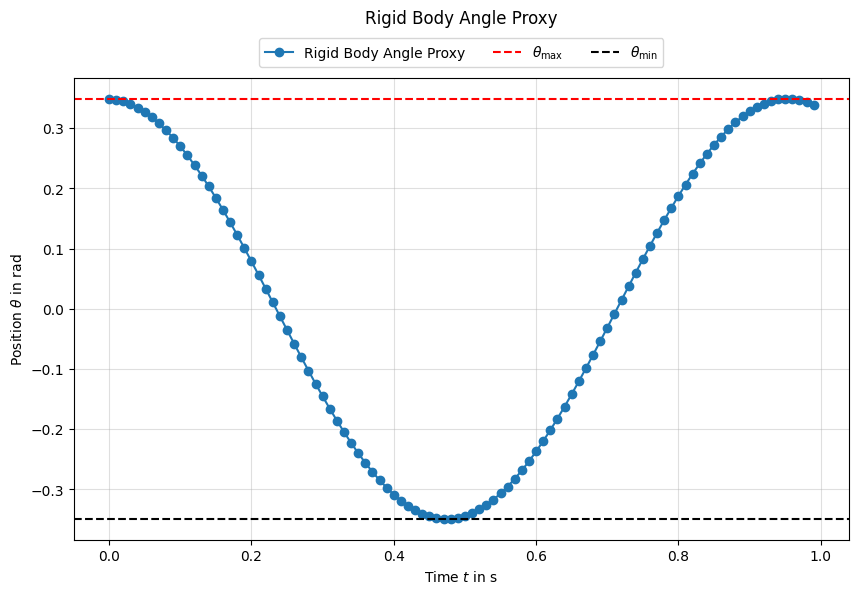

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals, theta_vals, marker='o', label='Rigid Body Angle Proxy')
plt.axhline(theta_vals[0], linestyle='--', color='r', label=r'$\theta_\max$')
plt.axhline(-theta_vals[0], linestyle='--', color='k', label=r'$\theta_\min$')
plt.title("Rigid Body Angle Proxy", y=1.1)
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Position $\theta$ in rad")
plt.grid(alpha=0.4)
plt.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.1))
plt.show()

## Conclusion

This tutorial demonstrated how to build a basic deformable pendulum model using the Finite Element Method with NGSolve.

We covered:
- geometry and mesh creation with named regions
- defining a Neo-Hookean hyperelastic material
- setting up a mixed FE space with a hinge constraint using `NumberSpace`
- assembling the nonlinear weak form (internal forces + inertia + gravity + constraints)
- time-integrating by solving the nonlinear weak form with Newton's method (NGSolve: `NewtonMinimization`) and Newmark-style updates
- extracting a rigid-body proxy angle from the deformable solution
